# Projekt 7

## Imie i Nazwisko
---

### Inicjalizacja potrzebnych bibliotek

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
%matplotlib inline

----
### 1. Wczytanie plików z danymi. Podstawowe statystyki. Wykres szeregu czasowego.

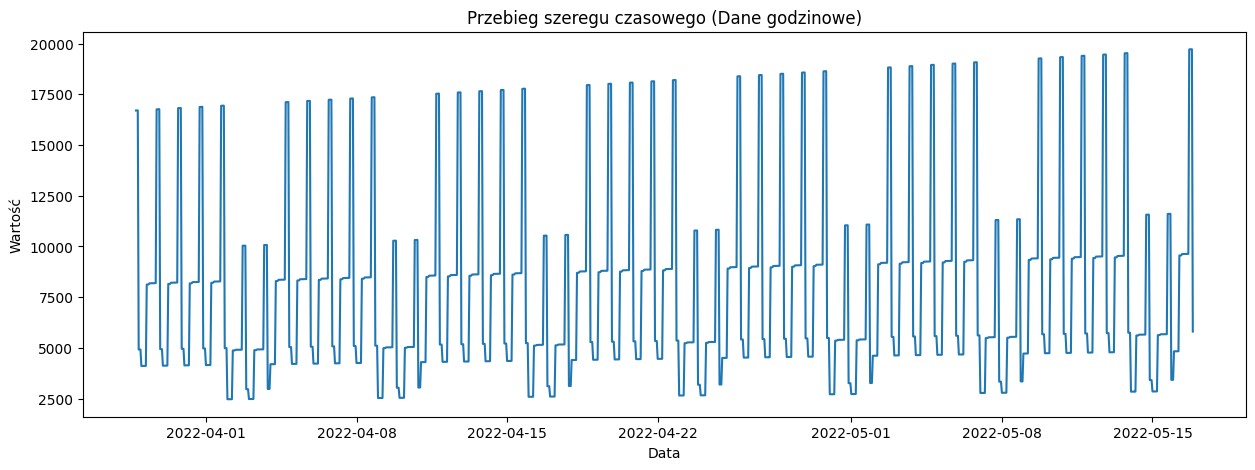

In [2]:
df = pd.read_csv("zuzycie_energii_16.csv")
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)
df = df.asfreq('h')

plt.figure(figsize=(15, 5))
plt.plot(df.index, df['value'])
plt.title('Przebieg szeregu czasowego (Dane godzinowe)')
plt.xlabel('Data')
plt.ylabel('Wartość')
plt.show()

---
### 2. Test stacjnonarności (ADF) szeregu czasowego.

In [3]:
#https://www.statsmodels.org/stable/examples/notebooks/generated/stationarity_detrending_adf_kpss.html
#H0 jest niestacjonarny (unit root)
adfuller(df['value'].dropna())

# p.v > 0.05, nie odrzucamy, jest niestacjonarne trzeba różnicować

(np.float64(-1.332761664660454),
 np.float64(0.6140537621381248),
 23,
 1156,
 {'1%': np.float64(-3.4360194465416387),
  '5%': np.float64(-2.8640434537995523),
  '10%': np.float64(-2.5681028978640104)},
 np.float64(20336.871023327676))

---
### 3. Różnicowanie i sezonowe różnicowanie szeregu czasowego. Badanie stacjonarności szeregu po różnicowaniu i sezonowym różnicowaniu. 

In [4]:
# zwykle
df['diff_1'] = df['value'].diff()
# dobowe
df['diff_season'] = df['value'].diff(24)
# zwykle + dobowe
df['diff_1_season'] = df['diff_1'].diff(24)

print(f"różnicowanie zwykle:  {adfuller(df['diff_1'].dropna())}")
print(f"różnicowanie sezonowe: {adfuller(df['diff_season'].dropna())}")
print(f"różnicowanie zwykle + sezonowe: {adfuller(df['diff_1_season'].dropna())}")
#H0 odrzucamy w każdym z przypadków, jest stacjonarny po każdym różnicowaniu

różnicowanie zwykle:  (np.float64(-6.2703766799094245), np.float64(4.017949676331338e-08), 23, 1155, {'1%': np.float64(-3.4360243661274414), '5%': np.float64(-2.8640456240825074), '10%': np.float64(-2.568104053709638)}, np.float64(18705.374098689284))
różnicowanie sezonowe: (np.float64(-4.896505242112709), np.float64(3.542474548827787e-05), 23, 1132, {'1%': np.float64(-3.436139921033549), '5%': np.float64(-2.86409660029079), '10%': np.float64(-2.568131202693254)}, np.float64(17996.5411956708))
różnicowanie zwykle + sezonowe: (np.float64(-9.000815187606326), np.float64(6.5051626524863425e-15), 23, 1131, {'1%': np.float64(-3.4361450520165464), '5%': np.float64(-2.8640988637413893), '10%': np.float64(-2.5681324081722314)}, np.float64(18003.841143527505))


---
### 4. Wykresy funkcji autokorelacji (ACF) i funkcji autokorelacji czastkowej (PACF) dla szeregu po różnicowaniu i sezonowym różnicowaniu.

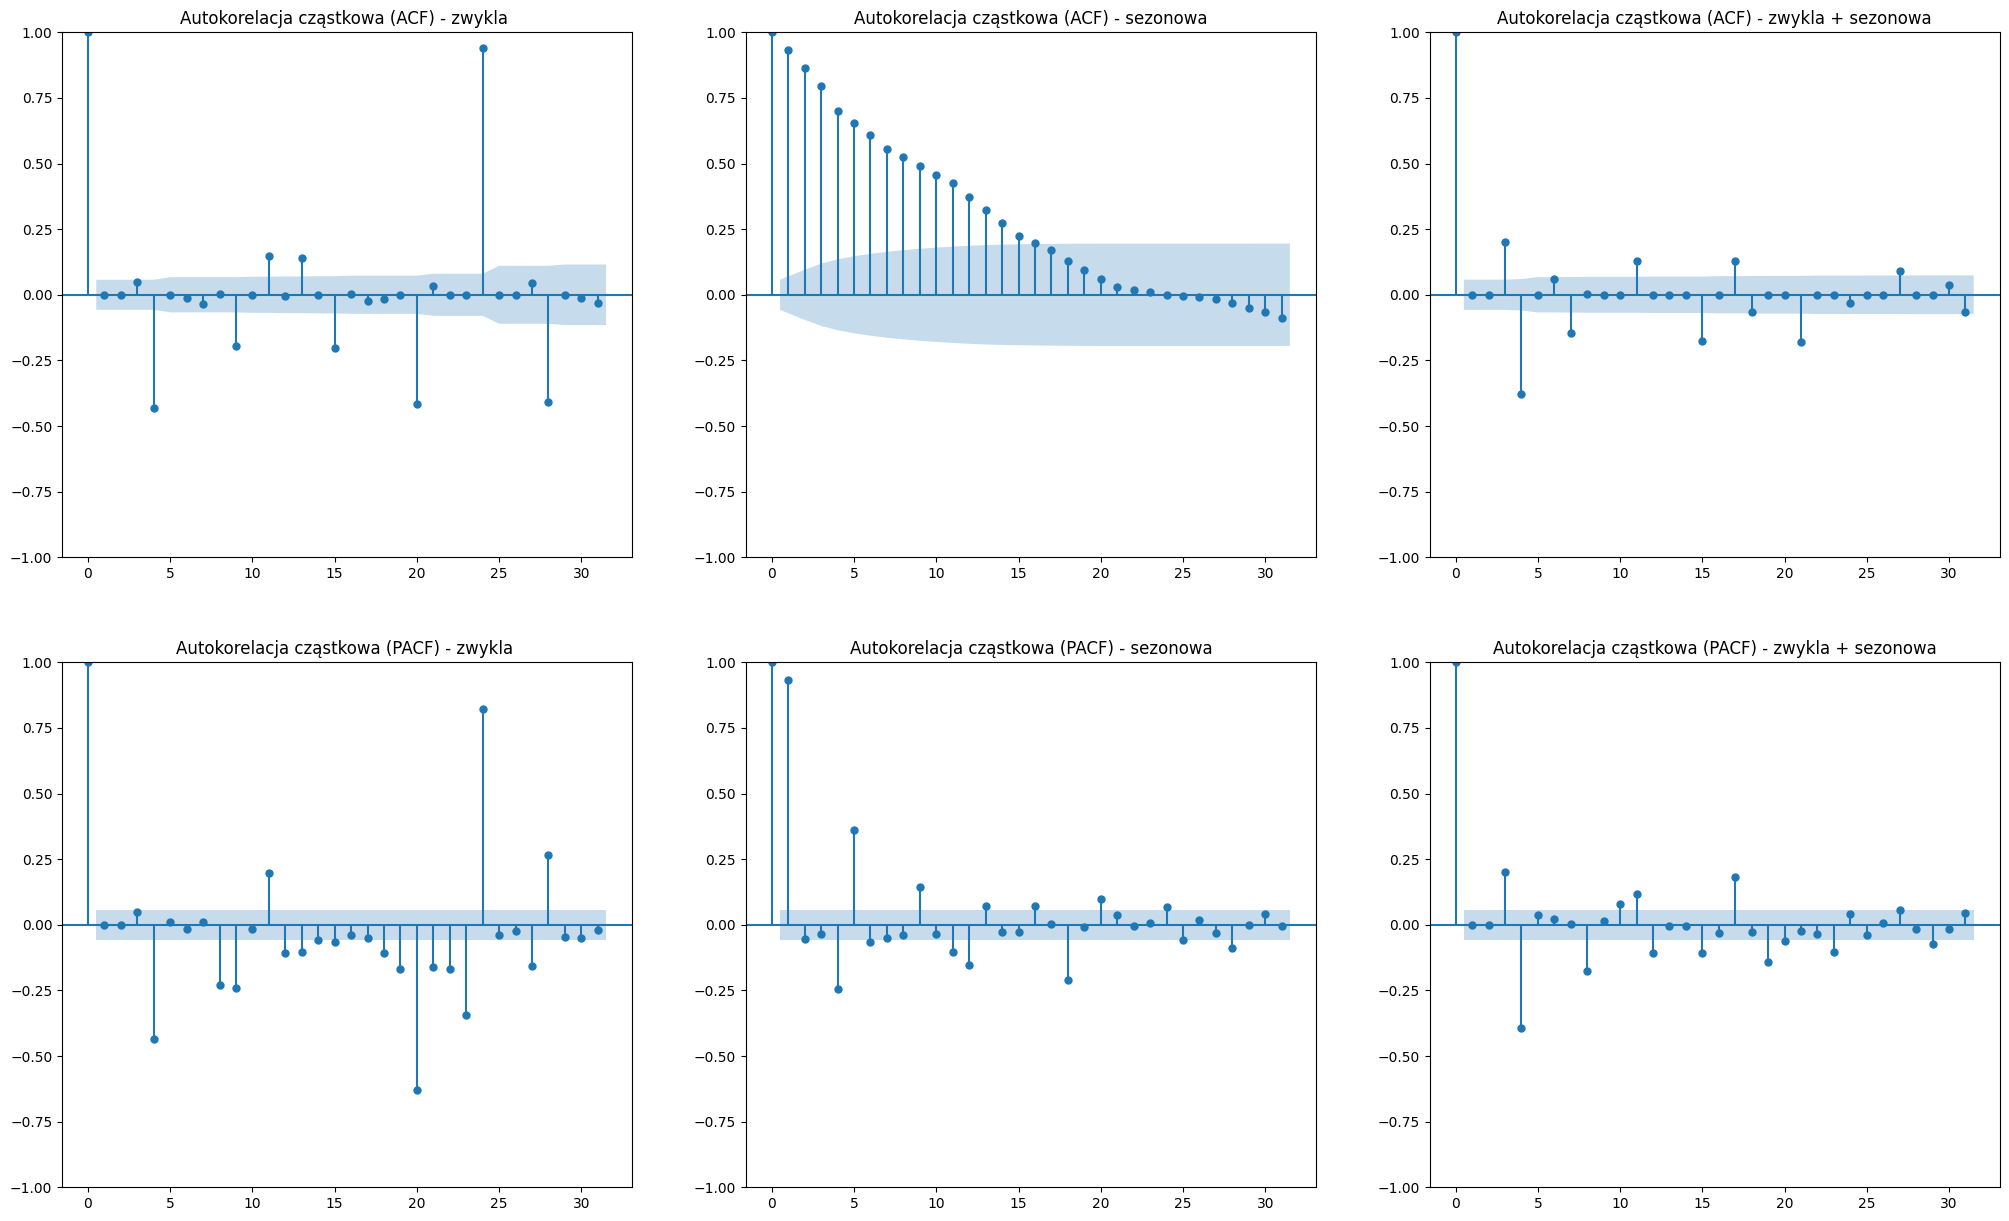

In [5]:
fig, ax = plt.subplots(2, 3, figsize=(25, 15))
plot_acf(df['diff_1'].dropna(), ax=ax[0][0], title="Autokorelacja cząstkowa (ACF) - zwykla ")
plot_acf(df['diff_season'].dropna(), ax=ax[0][1], title="Autokorelacja cząstkowa (ACF) - sezonowa")
plot_acf(df['diff_1_season'].dropna(), ax=ax[0][2], title="Autokorelacja cząstkowa (ACF) - zwykla + sezonowa")

plot_pacf(df['diff_1'].dropna(),ax=ax[1][0], title="Autokorelacja cząstkowa (PACF) - zwykla ")
plot_pacf(df['diff_season'].dropna(), ax=ax[1][1], title="Autokorelacja cząstkowa (PACF) - sezonowa")
plot_pacf(df['diff_1_season'].dropna(), ax=ax[1][2], title="Autokorelacja cząstkowa (PACF) - zwykla + sezonowa")
plt.show()

---
### 5. Utworzenie zbioru treningowego i testowego.

In [6]:
test_hours = 96 
train_data = df['value'].iloc[:-test_hours]
test_data = df['value'].iloc[-test_hours:]

print(f"Zakres treningowy: {train_data.index.min()} do {train_data.index.max()}")
print(f"Zakres testowy:    {test_data.index.min()} do {test_data.index.max()}")
print(f"Liczba próbek treningowych: {len(train_data)}")
print(f"Liczba próbek testowych: {len(test_data)}")

Zakres treningowy: 2022-03-28 18:00:00 do 2022-05-12 21:00:00
Zakres testowy:    2022-05-12 22:00:00 do 2022-05-16 21:00:00
Liczba próbek treningowych: 1084
Liczba próbek testowych: 96


---
### 6. Model ARIMA dla szeregu czasowego. Wyznaczenie prognozy oraz wyznaczenie MAE oraz RMSE

In [7]:
model_arima = ARIMA(train_data, order=(1,1,2))
results_arima = model_arima.fit()
forecast_arima_obj = results_arima.get_forecast(steps=len(test_data))
forecast_arima = forecast_arima_obj.predicted_mean
forecast_arima.index = test_data.index

print(f"MAE (Średni błąd bezwzględny): {mean_absolute_error(test_data, forecast_arima)}")
print(f"RMSE (Pierwiastek błędu średniokwadratowego): {np.sqrt(mean_squared_error(test_data, forecast_arima))}")

MAE (Średni błąd bezwzględny): 3316.3931310270586
RMSE (Pierwiastek błędu średniokwadratowego): 4639.042633862931


---
### 7. Model SARIMA dla szeregu czasowego. Wyznaczenie prognozy oraz wyznaczenie MAE oraz RMSE

In [8]:
#https://www.statsmodels.org/devel/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html

model_sarima = SARIMAX(train_data, 
                       order=(3,1,3), 
                       seasonal_order=(1,1,1,24),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

results_sarima = model_sarima.fit(disp=False)

forecast_sarima = results_sarima.get_forecast(steps=test_hours)
pred_sarima = forecast_sarima.predicted_mean
pred_sarima.index = test_data.index

print(f"SARIMA MAE: {mean_absolute_error(test_data, pred_sarima)}")
print(f"SARIMA RMSE: {np.sqrt(mean_squared_error(test_data, pred_sarima))}")

/opt/conda/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA MAE: 2054.1442671370123
SARIMA RMSE: 2717.5791436355985


---
### 8. Wykres zawierajacy zbiór testowy, prognozy ARIMA i SARIMA

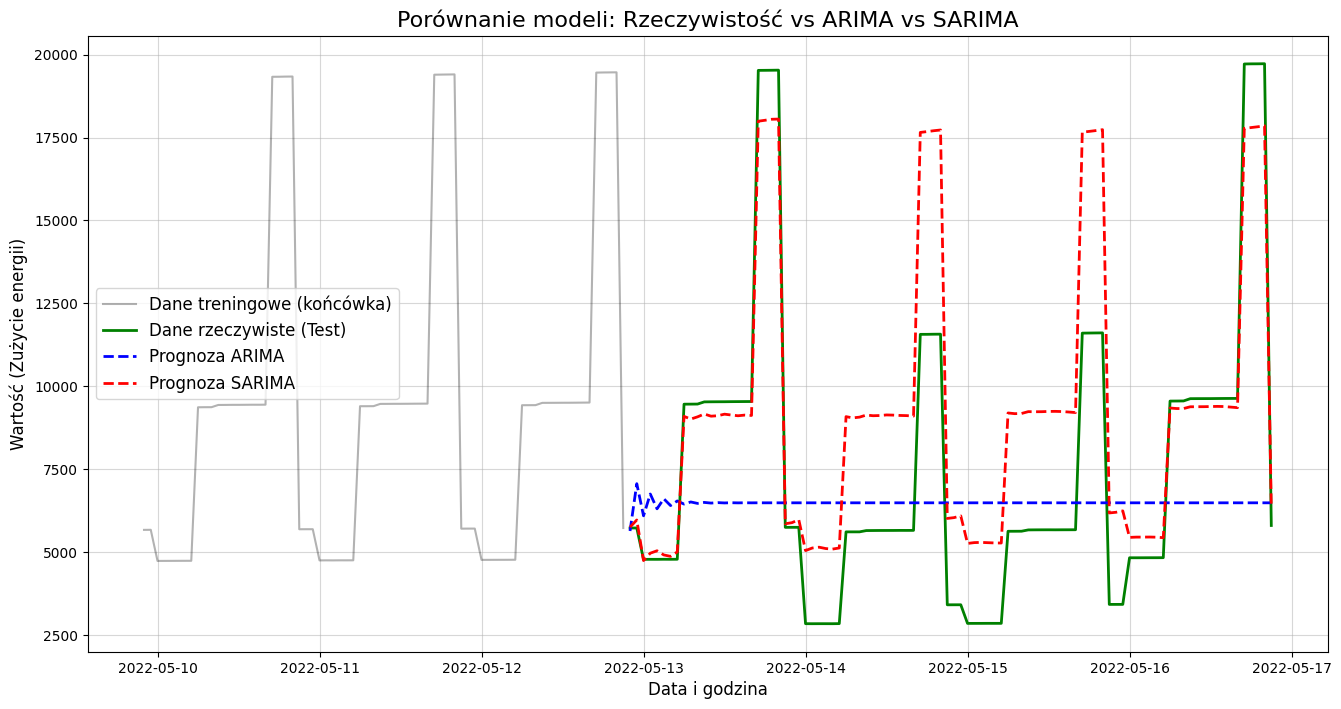

In [9]:
plt.figure(figsize=(16, 8))

plt.plot(train_data.index[-72:], train_data[-72:], label='Dane treningowe (końcówka)', color='black', alpha=0.3)

plt.plot(test_data.index, test_data, label='Dane rzeczywiste (Test)', color='green', linewidth=2)

plt.plot(test_data.index, forecast_arima, label='Prognoza ARIMA', color='blue', linestyle='--', linewidth=2)
plt.plot(test_data.index, pred_sarima, label='Prognoza SARIMA', color='red', linestyle='--', linewidth=2)

plt.title('Porównanie modeli: Rzeczywistość vs ARIMA vs SARIMA', fontsize=16)
plt.ylabel('Wartość (Zużycie energii)', fontsize=12)
plt.xlabel('Data i godzina', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.5)

plt.show()

## Wnioski:

####

Dla moich danych SARIMA jest odpowiednim wyborem, ze względu na sezonowość dzienną oraz dobową.
Brałem pod uwagę sezonowość dobową = 24, jednak rozsądnie byłoby wziąć pod uwagę też sezonowość tygodniową, ponieważ widać 05.15 to sobota a 05.16 to niedziela
parametr d został wyznaczony przy pomocy testów w moim przypadku = 1
parametry p i q, można wywnioskować z wykresów, jednak w moim przypadku starałem się dopasować takie wartości aby MSE i RMSE były jak najmniejsze

In [10]:
# Eksportowanie bieżacego notatnika do pdf.

%run ../data/notebook_export
export_notebook_to_pdf("Projekt7_Nocoń_Filip.ipynb")

Export 'Projekt7_Nocoń_Filip.ipynb': OK.


<Figure size 640x480 with 0 Axes>